change the features change the length size update the matrix like[;accuracy','recall',precision'] update all the hyperparameters like block size learning rate activation function then add the new layer such as dropout layer try tpo improve the accuracy this model by adding lstm layer

In [5]:
import tensorflow as tf
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

GPUs Available: []


Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 160ms/step - accuracy: 0.6599 - loss: 0.5991 - precision: 0.6443 - recall: 0.7914 - val_accuracy: 0.8616 - val_loss: 0.3312 - val_precision: 0.8825 - val_recall: 0.8303
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 163ms/step - accuracy: 0.8950 - loss: 0.2657 - precision: 0.8959 - recall: 0.8950 - val_accuracy: 0.8738 - val_loss: 0.3329 - val_precision: 0.8518 - val_recall: 0.9012
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.9410 - loss: 0.1717 - precision: 0.9438 - recall: 0.9374 - val_accuracy: 0.8818 - val_loss: 0.2975 - val_precision: 0.8999 - val_recall: 0.8558
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.9542 - loss: 0.1301 - precision: 0.9556 - recall: 0.9526 - val_accuracy: 0.8748 - val_loss: 0.3355 - val_precision: 0.8568 - val_recall: 0.8963
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.9645 - loss: 0.1086 - precision: 0.9648 - recall: 0.9646 - val_accuracy: 0.8762

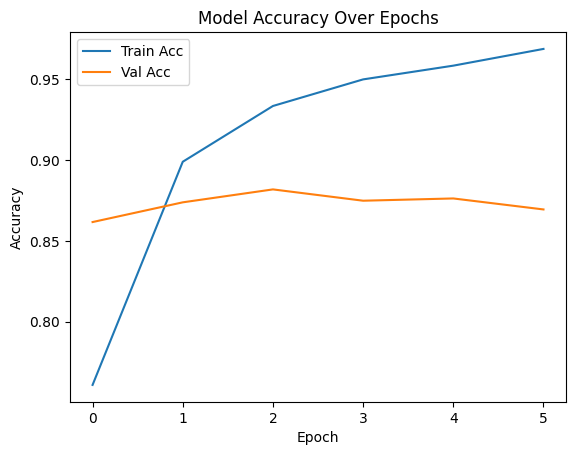

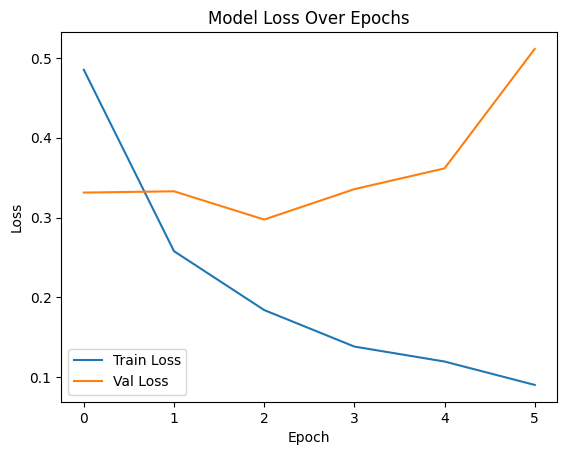

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Predicted Sentiment: Negative


In [6]:
# 1. Import Libraries
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


# 2. Updated Parameters
max_features = 15000      # Increased vocabulary size
maxlen = 300              # Reduced sequence length to improve training speed
embedding_dim = 64        # Increased embedding size


# 3. Load Dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# 4. Pad Sequences
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)


# 5. Build Improved Model with LSTM + Dropout
model = Sequential()

# Embedding Layer
model.add(Embedding(max_features, embedding_dim, input_length=maxlen))

# Add dropout to reduce overfitting
model.add(Dropout(0.4))

# LSTM Layer (improves accuracy)
model.add(LSTM(64, return_sequences=False, activation='tanh'))
# Dropout again
model.add(Dropout(0.1))

# Dense Output Layer
model.add(Dense(1, activation='sigmoid'))


# 6. Compile Model with New Hyperparameters
learning_rate = 0.0005   # Smaller LR helps improve accuracy
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)


# 7. Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=6,
    batch_size=32,       # Smaller batch size often improves learning
    validation_split=0.2
)


# 8. Evaluate Model
test_loss, test_acc, test_precision, test_recall = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


# 9. Training Curves
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Acc', 'Val Acc'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.show()


# 10. Prediction on Sample Review
sample_review = np.expand_dims(x_test[0], axis=0)
prediction = model.predict(sample_review)[0][0]

if prediction > 0.5:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")
